# SFWM Project

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import hamhelper.plotting as hp
import hamhelper.colours as hc
from tabulate import tabulate

## User Configuration

In [89]:
# Constants
c= 2.9979e8             # Speed of light in m/s
h_planck = 6.62607e-34  # J*s

# User params
wl_pump  =   1310.0  * 1e-9  # pump wavelength in meters
fsr_targ =      0.57 * 1e-9   # Target FSR in nm
dc_coupling =   0.98

# Simulated params @ 1310nm
n_eff  =     1.3797
dn_dwl =     0.1 * 1e-9  # nm - Not in use, MODE gives n_g directly
n_g    =     2.741015
beta2  =    -5.0 * 1e-26  # Generic
atten_dBcm = 0.8
A_eff  =     0.338835 * 1e-12  # um^2 -> m^2
n2     =     2.4 * 1e-19  # m^2/W - Generic

# Derived parameters
# n_g = n_eff - wl_pump * dn_dwl
v_g = c / n_g

# Print pretty table using tabulate
print(tabulate([['n_eff', n_eff], ['dn_dwl', dn_dwl], ['beta2', beta2], ['atten_dBcm', atten_dBcm], ['A_eff', A_eff], ['n2', n2]], headers=['Parameter', 'Value'], tablefmt='grid'))

+-------------+--------------+
| Parameter   |        Value |
+=============+==============+
| n_eff       |  1.3797      |
+-------------+--------------+
| dn_dwl      |  1e-10       |
+-------------+--------------+
| beta2       | -5e-26       |
+-------------+--------------+
| atten_dBcm  |  0.8         |
+-------------+--------------+
| A_eff       |  3.38835e-13 |
+-------------+--------------+
| n2          |  2.4e-19     |
+-------------+--------------+


## FSR and Ring Sizing

In [87]:
# Estimate geometry from target
L_est = wl_pump**2 / (n_g * fsr_targ)  # In nm
m_est= n_eff * L_est / wl_pump
m_est_rounded = round(m_est)

# Match L exactly to rounded mode number
L_0 = m_est_rounded * wl_pump / n_eff
R_0 = L_0 / (2 * np.pi)

# Calculate FSR
D1 = 2 * np.pi * v_g / L_0
fsr_0_nm = wl_pump**2 * D1 / (2 * np.pi * c)

print(f"Resonant Mode (m): {m_est_rounded} | Exact Radius: {R_0*1e6:.2f} um -> Verified FSR: {fsr_0_nm*1e9:.2f} nm")

Resonant Mode (m): 1157 | Exact Radius: 174.84 um -> Verified FSR: 0.57 nm


In [74]:
# Convert to frequency omega
omega_pump = 2 * np.pi * c / wl_pump
omega_range = wl_sim_range * 2 * np.pi * c / (wl_pump**2)  # Convert wavelength range to frequency range
omega_range = 1.5 * D1

# Generate frequency grid
omega_arr = np.linspace(omega_pump - omega_range, omega_pump + omega_range, 20000)
wl_arr = 2 * np.pi * c / omega_arr

# Reconstruct dispersion-aware propagation constant beta(omega)
beta0 = omega_pump * n_eff / c
beta1 = 1.0 / v_g
beta_arr = beta0 + beta1 * (omega_arr - omega_pump) + 0.5 * beta2 * (omega_arr - omega_pump)**2

# Round-trip phase calculation
theta_arr = beta_arr * L_0

print(f"Round trip loss  =    {atten_dBcm * L_0 * 100:.2f} dB")
print(f"Round trip phase = {theta_arr[np.argmin(np.abs(omega_arr - omega_pump))] / (2 * np.pi):.2f} cycles")

Round trip loss  =    0.10 dB
Round trip phase = 1319.00 cycles


In [78]:
atten_dB_m = atten_dBcm * 100
loss_roundtrip = atten_dB_m * L_0
a = 10**(-loss_roundtrip / 20) # Internal amplitude round-trip transmission

# Define transmission coupling coefficient (t)
t = dc_coupling * a

# Transmission & Field Enhancement Profiles
transmission_thru = (t - a * np.exp(-1j * theta_arr)) / (1 - a * t * np.exp(-1j * theta_arr))
thru_dB = 10 * np.log10(np.abs(transmission_thru)**2)

kappa = np.sqrt(1 - t**2)
fe_amplitude = np.abs(kappa / (1 - a * t * np.exp(-1j * theta_arr)))
power_buildup = fe_amplitude**2
fe_peak = kappa / (1 - a * t)

print(f"Coupling coefficient (t) = {t:.4f} at (a) = {a:.4f}")
print(f"Field Enhancement (FE) peak: {fe_peak:.2f} & Power buildup: {fe_peak**2:.2f}")

Coupling coefficient (t) = 0.9688 at (a) = 0.9885
Field Enhancement (FE) peak: 5.86 & Power buildup: 34.29



Integrated Dispersion D_int: 0.13 MHz
Intracavity Power Needed for Phase Matching: 0.001 W
Required Input Bus Waveguide Power         : 0.03 mW


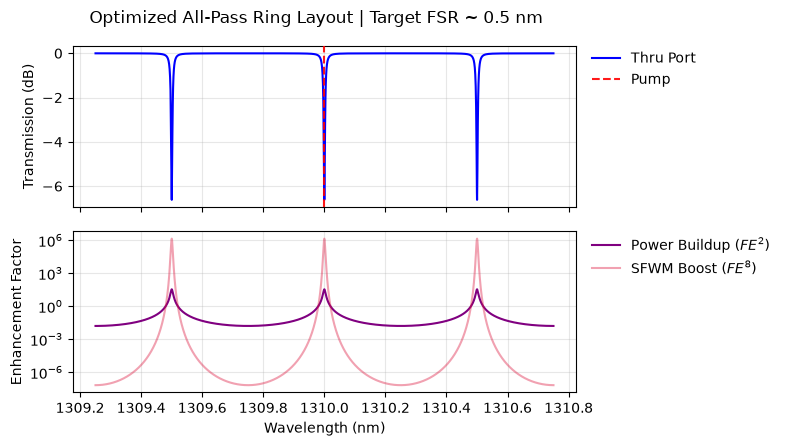

In [69]:
# SFWM and Dispersion Analysis
# D2 calculation: FSR change rate per mode step
D2 = - v_g * beta2 * (D1**2)
D_int_mu1 = 0.5 * D2 * (1**2) # Mismatch at 1st sideband pair (rad/s)

# Nonlinear power
gamma_nl =2 * np.pi * n2 / (wl_pump * A_eff)  # Nonlinear coefficient (1/W/m)
req_p_intra = D_int_mu1 / (2 * v_g * gamma_nl) if D2 > 0 else 0
req_p_bus = req_p_intra / (fe_peak**2) if D2 > 0 else 0

# Print final diagnostic log
print("\n" + "="*80)
print(f"Integrated Dispersion D_int: {D_int_mu1 / (2 * np.pi * 1e6):.2f} MHz")
print(f"Intracavity Power Needed for Phase Matching: {req_p_intra:.3f} W")
print(f"Required Input Bus Waveguide Power         : {req_p_bus*1e3:.2f} mW")
print("="*80)

# Build Verification Graphics
fig, (ax_thru, ax_fe) = plt.subplots(2, 1, figsize=(6.5, 4.5), sharex=True)
fig.subplots_adjust(hspace=0.15)

# Thru Transmission
ax_thru.plot(wl_arr * 1e9, thru_dB, color='blue', label='Thru Port')
ax_thru.axvline(x=wl_pump * 1e9, color='red', linestyle='--', alpha=0.9, label='Pump', zorder=100)
ax_thru.set_ylabel('Transmission (dB)')
ax_thru.grid(True, alpha=0.3)
ax_thru.legend(loc='upper left', bbox_to_anchor=(1.02, 1.0), borderaxespad=0., framealpha=0)

# Field Enhancement Scaling Profiles
ax_fe.plot(wl_arr * 1e9, power_buildup, color='purple', label='Power Buildup ($FE^2$)')
ax_fe.plot(wl_arr * 1e9, fe_amplitude**8, color='crimson', alpha=0.4, label='SFWM Boost ($FE^8$)')
ax_fe.set_ylabel('Enhancement Factor')
ax_fe.set_xlabel('Wavelength (nm)')
ax_fe.set_yscale('log')
ax_fe.grid(True, alpha=0.3)
ax_fe.legend(loc='upper left', bbox_to_anchor=(1.02, 1.0), borderaxespad=0., framealpha=0)

plt.suptitle(f'Optimized All-Pass Ring Layout | Target FSR ~ {fsr_targ*1e9:.1f} nm', y=0.96)
plt.show()


## Regarding the Filters

In [ ]:
# FSR needed for filtering the pump is twice the FSR of the ring
fsr_filter = 2 * fsr_0_nm

# How much attenuation we need to filter out the pump afterwards and see the SFWM idler and signal
# Assume FE about the same for the pump, signal and idler


In [ ]:
E_pump_light = (h_planck * c_light) / wl_pump  # Joules per photon at 1310 nm

# 2. Extract Coupling Matrix Elements from Your Existing t and a\
cavity_roundtrip_time = L_0 / v_g
# Full cavity linewidth (HWHM in rad/s) combining internal losses and coupling
gamma_cavity_rad = (1 - a*t) / cavity_roundtrip_time  
linewidth_Hz = gamma_cavity_rad / np.pi  

# Select an active pump power operating point in the bus waveguide (e.g., 10 mW)
P_bus_operational = 20.0e-3  # 10 mW baseline input

# Canonical microring SFWM PGR expression (scaled by fe_peak**8)
# Factor of 0.5 accounts for degenerate photon pair combinations
PGR_analytical = 0.5 * linewidth_Hz * ((gamma_nl * L_0 * P_bus_operational) ** 2) * (fe_peak ** 8)

# 4. Quantitative Filter Assessment
target_snr = 10.0  # Require signal flux to be 10x stronger than leaked noise
signal_power_watts = PGR_analytical * E_pump_light
max_leak_pump_watts = signal_power_watts / target_snr

# Calculate precise required isolation
laser_power_dBm = 10 * np.log10(P_bus_operational / 1e-3)
total_rejection_needed_dB = 10 * np.log10(P_bus_operational / max_leak_pump_watts)

# Pull the native ring suppression (Thru port transmission away from resonance)
# Evaluating at the edge of the array (at +/- 1 FSR distance from the 1310 pump)
native_ring_rejection_dB = np.abs(thru_dB[0])  

net_external_filter_need_dB = total_rejection_needed_dB - native_ring_rejection_dB
estimated_stages = np.ceil(net_external_filter_need_dB / native_ring_rejection_dB)

# 5. Output Rigorous Physical Report
print("\n" + "="*80)
print("     QUANTUM PHOTONICS FILTER REQUIREMENTS REPORT")
print("="*80)
print(f"Operational Input Pump Power      : {P_bus_operational*1e3:.2f} mW ({laser_power_dBm:.2f} dBm)")
print(f"Cavity Resonance Linewidth (FWHM) : {linewidth_Hz*2/1e6:.2f} MHz")
print(f"Derived Photon Pair Gen Rate (PGR): {PGR_analytical:.2e} pairs/sec (Hz)")
print(f"Total Single-Photon Channel Flux  : {signal_power_watts*1e15:.3f} fW")
print("-"*80)
print(f"Total Necessary Pump Rejection    : {total_rejection_needed_dB:.2f} dB")
print("="*80 + "\n")



     QUANTUM PHOTONICS FILTER REQUIREMENTS REPORT
Operational Input Pump Power      : 20.00 mW (13.01 dBm)
Cavity Resonance Linewidth (FWHM) : 2684.18 MHz
Derived Photon Pair Gen Rate (PGR): 5.17e+06 pairs/sec (Hz)
Total Single-Photon Channel Flux  : 784.003 fW
--------------------------------------------------------------------------------
Total Necessary Pump Rejection    : 114.07 dB

